In [756]:
import pandas as pd
import numpy as np
import re
import nltk
import streamlit as st
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import contractions

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import scipy.sparse as sp

In [757]:
print("*"*50)
print("Loading data...")
df = pd.read_csv("C:/Users/HP/OneDrive/Documents/imdb/imdb_movies.csv")
print("*"*50)

**************************************************
Loading data...
**************************************************


In [758]:
df.shape

(4305, 5)

In [759]:
df.head(10)

,title,duration,rating,vote_count,storyline
0,Relay,1h 52m,7.0,28K,A broker of lucrative payoffs between corrupt ...
1,Dune: Part Two,2h 46m,8.4,712K,Paul Atreides unites with the Fremen while on ...
2,Civil War,1h 49m,7.0,262K,"In a dystopian future, four journalists travel..."
3,Gladiator II,2h 28m,6.5,287K,After his home is conquered by the tyrannical ...
4,Deadpool & Wolverine,2h 8m,7.5,551K,Deadpool is offered a place in the Marvel Cine...
5,Abigail,1h 49m,6.5,113K,After a group of criminals kidnap the ballerin...
6,The Ministry of Ungentlemanly Warfare,2h 2m,6.8,153K,The British military recruits a small group of...
7,The Fall Guy,2h 6m,6.8,250K,"A stuntman, fresh off an almost career-ending ..."
8,The Instigators,1h 41m,6.2,42K,Follows two robbers who must go on the run wit...
9,The Beekeeper,1h 45m,6.3,175K,A former operative of a powerful organization ...


In [760]:
df

,title,duration,rating,vote_count,storyline
0,Relay,1h 52m,7.0,28K,A broker of lucrative payoffs between corrupt ...
1,Dune: Part Two,2h 46m,8.4,712K,Paul Atreides unites with the Fremen while on ...
2,Civil War,1h 49m,7.0,262K,"In a dystopian future, four journalists travel..."
3,Gladiator II,2h 28m,6.5,287K,After his home is conquered by the tyrannical ...
4,Deadpool & Wolverine,2h 8m,7.5,551K,Deadpool is offered a place in the Marvel Cine...
...,...,...,...,...,...
4300,Macproud,NaN,NaN,NaN,A man and his soul are connected between reali...
4301,Planet Magnon,1h 32m,NaN,NaN,NaN
4302,Labyrint more,1h 1m,NaN,NaN,Do we live in a simulation? The life of show h...
4303,Miss Roboto,NaN,NaN,NaN,NaN


In [761]:
df.sample(10)

,title,duration,rating,vote_count,storyline
2997,The Victims,1h 39m,5.8,105,"Yuan Wenshan, a police officer, discovers the ..."
4216,Carjorski Clan: Tale of the Fallen Knight,NaN,NaN,NaN,After a brutal event that changes his life for...
2207,Ryan's World the Movie: Titan Universe Adventure,1h 20m,1.8,832,Ryan's twin sisters Emma and Kate get trapped ...
898,War with the Evil,1h 25m,6.2,55,"Orphaned two men and a woman robbers, armed wi..."
3080,The Hostage,1h 27m,4.2,31,"When two amateur drug dealers, Jeremy and Will..."
3219,Halfway House Series,1h 40m,NaN,NaN,Seven troubled adult men struggle to live toge...
4222,The Burned Hand,1h 25m,7.3,13,"On a stormy night, Dr. Maxwell burns his right..."
1798,Tapori Nayak,NaN,8.6,18,Movie(End of the World) dubbed from Hollywood ...
4170,El origen de las especies,1h 11m,NaN,NaN,A misty jungle opens the confines of time and ...
709,Bolice,1h 42m,7.9,16,"After being sidelined, the Tunisian Prime Mini..."


In [762]:
df.duplicated().sum()

np.int64(869)

In [763]:
df.isnull().sum()

title            0
duration       745
rating        1266
vote_count    1266
storyline      584
dtype: int64

In [764]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4305 entries, 0 to 4304
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       4305 non-null   object 
 1   duration    3560 non-null   object 
 2   rating      3039 non-null   float64
 3   vote_count  3039 non-null   object 
 4   storyline   3721 non-null   object 
dtypes: float64(1), object(4)
memory usage: 168.3+ KB


In [765]:

##handling duplicates
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df)}")

Rows after removing duplicates: 3436


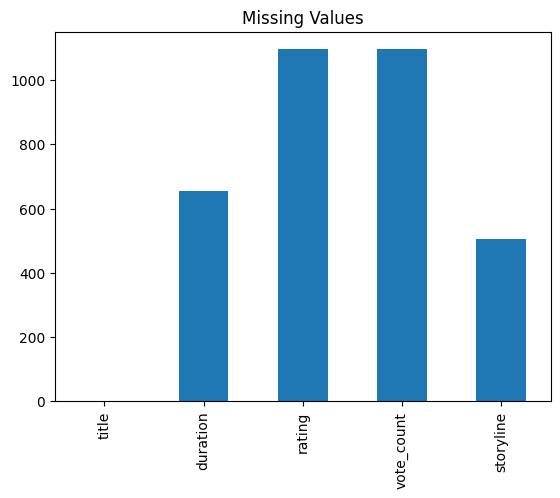

In [766]:
plt.figure()
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values")
plt.show()

In [767]:
#handling missing values
df = df.dropna(subset=['storyline'])

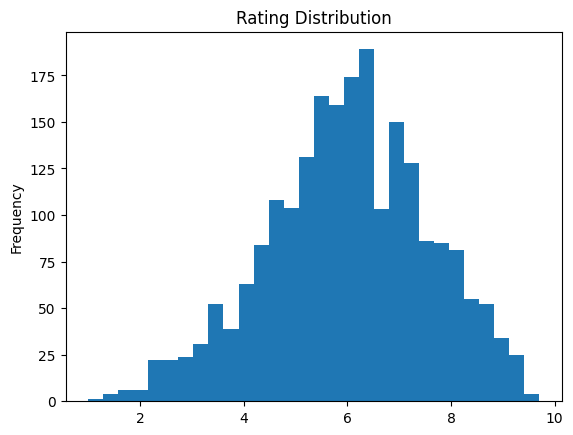

In [768]:
plt.figure()
df['rating'].plot(kind='hist', bins=30)
plt.title("Rating Distribution")
plt.show()

In [769]:
df['rating'].mean()

np.float64(6.003888380603843)

In [770]:
df['rating'].median()

np.float64(6.1)

In [771]:
# Use sampling method
valid_ratings = df['rating'].dropna()

df.loc[df['rating'].isna(), 'rating'] = valid_ratings.sample(
    df['rating'].isna().sum(),
    replace=True
).values

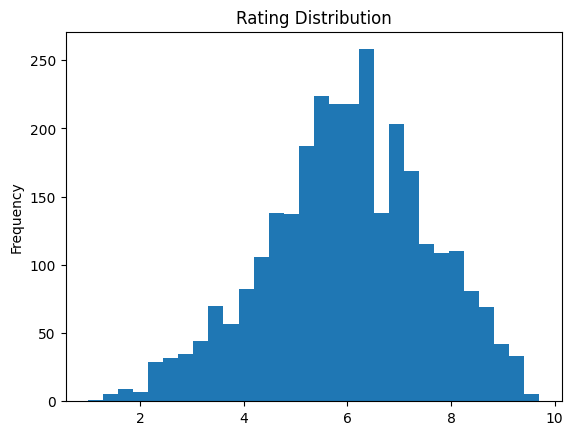

In [772]:
plt.figure()
df['rating'].plot(kind='hist', bins=30)
plt.title("Rating Distribution")
plt.show()

In [773]:
print("*"*50)
print("handling null value for vote_count")
print("*"*50)

**************************************************
handling null value for vote_count
**************************************************


In [774]:
def convert_votes(vote):
    if pd.isna(vote):
        return np.nan
    vote = str(vote).replace(',', '').upper().strip()
    try:
        if 'K' in vote:
            return float(vote.replace('K', '')) * 1000
        elif 'M' in vote:
            return float(vote.replace('M', '')) * 1000000
        else:
            return float(vote)
    except:
        return np.nan

df['vote_count'] = df['vote_count'].apply(convert_votes)


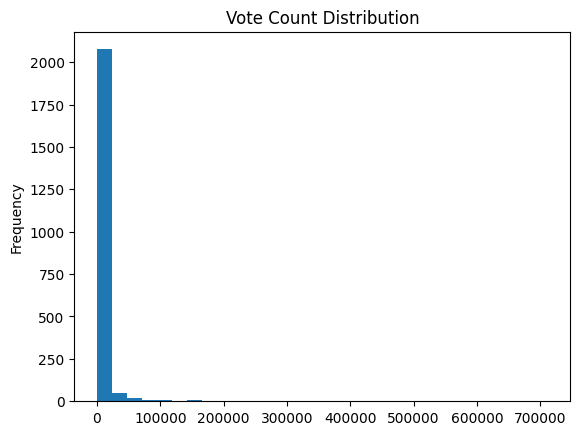

In [775]:
plt.figure()
df['vote_count'].plot(kind='hist', bins=30)
plt.title("Vote Count Distribution")
plt.show()

In [776]:
df['vote_count'].value_counts()

vote_count
14.0     34
18.0     34
9.0      31
13.0     29
7.0      29
         ..
526.0     1
129.0     1
574.0     1
449.0     1
126.0     1
Name: count, Length: 662, dtype: int64

In [777]:
# Use this (same as your rating method)
valid_vote_counts = df['vote_count'].dropna()
df.loc[df['vote_count'].isna(), 'vote_count'] = valid_vote_counts.sample(
    df['vote_count'].isna().sum(),
    replace=True
).values
print(f"Vote count nulls after fill: {df['vote_count'].isnull().sum()}")

Vote count nulls after fill: 0


In [778]:
df['vote_count'] = df['vote_count'].astype(int)

In [779]:
df['vote_count'].value_counts()

vote_count
18     55
14     46
9      40
13     39
10     37
       ..
235     1
367     1
296     1
217     1
496     1
Name: count, Length: 662, dtype: int64

In [780]:
#converting duration to mins
def duration_to_mins(dur_str):
    if pd.isna(dur_str):
        return np.nan
    dur_str = str(dur_str).lower()
    hour_match = re.search(r'(\d+)h', dur_str)
    minute_match = re.search(r'(\d+)m', dur_str)
    hours = int(hour_match.group(1)) if hour_match else 0
    minutes = int(minute_match.group(1)) if minute_match else 0
    total = hours * 60 + minutes
    return total if total > 0 else np.nan

In [781]:
df['duration_mins'] = df['duration'].apply(duration_to_mins)
median_duration = df['duration_mins'].median()
df['duration_mins'] = df['duration_mins'].fillna(median_duration)
print(f"Duration nulls after fill: {df['duration_mins'].isnull().sum()}")


Duration nulls after fill: 0


In [782]:
df['duration_mins'] = df['duration_mins'].astype(int)

In [783]:
df.head()

,title,duration,rating,vote_count,storyline,duration_mins
0,Relay,1h 52m,7.0,28000,A broker of lucrative payoffs between corrupt ...,112
1,Dune: Part Two,2h 46m,8.4,712000,Paul Atreides unites with the Fremen while on ...,166
2,Civil War,1h 49m,7.0,262000,"In a dystopian future, four journalists travel...",109
3,Gladiator II,2h 28m,6.5,287000,After his home is conquered by the tyrannical ...,148
4,Deadpool & Wolverine,2h 8m,7.5,551000,Deadpool is offered a place in the Marvel Cine...,128


In [784]:
df.drop(['duration'],axis=1,inplace=True)
df.sample(3)

,title,rating,vote_count,storyline,duration_mins
1174,Dheera Bhagat Roy,8.0,1100,"Set in 1970s Karnataka, during the land reform...",150
723,Mister Gates,8.5,33,Real-estate mogul Christopher Gates becomes ho...,95
3629,The Rabble Story,5.3,288,"When a very important man is killed, Detective...",18


In [785]:
print("*"*50)
print("clean story line NLP")
print("*"*50)

**************************************************
clean story line NLP
**************************************************


In [786]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [787]:
df.isnull().sum()

title            0
rating           0
vote_count       0
storyline        0
duration_mins    0
dtype: int64

In [788]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2931 entries, 0 to 4304
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          2931 non-null   object 
 1   rating         2931 non-null   float64
 2   vote_count     2931 non-null   int64  
 3   storyline      2931 non-null   object 
 4   duration_mins  2931 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 137.4+ KB


In [789]:
stop_words=set(stopwords.words('english'))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [790]:
lemmatizer=WordNetLemmatizer()

In [791]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = str(text).lower()
    #  Expand contractions: "don't" - "do not"
    text = contractions.fix(text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = ' '.join([w for w in text.split() if w.isalpha()])
    # Tokenize
    tokens = word_tokenize(text)
    #  Remove stopwords and lemmatize
    cleaned = ' '.join([lemmatizer.lemmatize(word) for word in tokens if word not in stop_words])
    return cleaned



In [792]:
clean_text('In a dystopian future, four journalists travel across the United States during a nation-wide conflict. While trying to survive, they aim to reach the White House to interview the president before he is overthrown.',)

'dystopian future four journalist travel across united state nationwide conflict trying survive aim reach white house interview president overthrown'

In [793]:
df['clean_storyline'] = df['storyline'].apply(clean_text)

In [794]:
df.drop(['storyline'],axis=1,inplace=True)  

In [795]:
df.head()

,title,rating,vote_count,duration_mins,clean_storyline
0,Relay,7.0,28000,112,broker lucrative payoff corrupt corporation in...
1,Dune: Part Two,8.4,712000,166,paul atreides unites fremen warpath revenge co...
2,Civil War,7.0,262000,109,dystopian future four journalist travel across...
3,Gladiator II,6.5,287000,148,home conquered tyrannical emperor lead rome lu...
4,Deadpool & Wolverine,7.5,551000,128,deadpool offered place marvel cinematic univer...


In [796]:
print("*"*50)
print("Build TF-IDF matrix")
print("*"*50)

**************************************************
Build TF-IDF matrix
**************************************************


In [797]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df['clean_storyline'])

print(tfidf_matrix.shape)


(2931, 5000)


In [798]:


cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

cosine_sim.shape

(2931, 2931)

In [799]:
def recommend_movies(user_story, top_n=5):

    user_story = clean_text(user_story)
    if not user_story.strip():
        print("Input is empty after cleaning. Try a longer description.")
        return pd.DataFrame()
    user_vector = tfidf.transform([user_story])
    similarity_scores = cosine_similarity(user_vector, tfidf_matrix).flatten()  
    top_indices = similarity_scores.argsort()[::-1][:top_n]
    
    #build result with .copy() to avoid SettingWithCopyWarning
    recommendations = df.iloc[top_indices][['title', 'clean_storyline', 'rating', 'duration_mins']].copy()
    recommendations['similarity_score'] = (similarity_scores[top_indices] * 100).round(2)
    recommendations = recommendations.reset_index(drop=True)
    recommendations.index = recommendations.index + 1  # rank starts from 1
    
    return recommendations


In [806]:

user_input = "hero save the world"
result = recommend_movies(user_input, top_n=5)
print(result[['title', 'rating', 'similarity_score']])

                                         title  rating  similarity_score
1                                   Boundearth     9.0             36.18
2  Doraemon the Movie: Nobita's Earth Symphony     6.6             34.05
3                                       Saturn     7.6             32.75
4             Motu Patlu & The Rise of Zombies     7.7             31.36
5                                    Submerged     6.3             30.36


In [801]:

# Save all data and models — app.py will load these 3 files
df.to_csv("imdb_cleaned.csv", index=False)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

sp.save_npz("tfidf_matrix.npz", tfidf_matrix)

print("Saved — ready to build Streamlit app")

Saved — ready to build Streamlit app
